In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading And EDA

In [2]:
df=pd.read_csv(r"C:\Users\bisha\OneDrive\Desktop\EmployeeAttrition_Bishal_Anand\WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

- There are 35 columns, and attrition information is present in the column name attrition.
- Out of 35 columns 9 columns are of object type and 24 column are of integer type. 

In [5]:
yes_att=(df['Attrition']=='Yes').sum()
percent_leave=(yes_att/len(df))*100
print(f"percentage of employee who attrit {percent_leave}%")

percentage of employee who attrit 16.122448979591837%


## Insights
The percentage of employees who attrit is very low, which will create a biased model if left unhandled. However, we will address this class imbalance later in our pipeline.

# EDA

In [6]:
#Number of unique values
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [7]:
df.isnull().count()

Age                         1470
Attrition                   1470
BusinessTravel              1470
DailyRate                   1470
Department                  1470
DistanceFromHome            1470
Education                   1470
EducationField              1470
EmployeeCount               1470
EmployeeNumber              1470
EnvironmentSatisfaction     1470
Gender                      1470
HourlyRate                  1470
JobInvolvement              1470
JobLevel                    1470
JobRole                     1470
JobSatisfaction             1470
MaritalStatus               1470
MonthlyIncome               1470
MonthlyRate                 1470
NumCompaniesWorked          1470
Over18                      1470
OverTime                    1470
PercentSalaryHike           1470
PerformanceRating           1470
RelationshipSatisfaction    1470
StandardHours               1470
StockOptionLevel            1470
TotalWorkingYears           1470
TrainingTimesLastYear       1470
WorkLifeBa

In [8]:
#checking number of values
for cols in df.columns:
    if df[cols].dtype == 'object':
        print(df[cols].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
Gender
Male      882
Female    588
Name: count, dtype: int64
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64
Over18
Y    1470
Name: count,

- Employee count and Employee Number do not impact our model if we delete it that's why we remove them.
- Also, over 18 do not play any role, and we can infer it directly from the age column, so we also remove it.
- Also, StandardHours do not play any important role.

In [9]:
#Removing unwanted columns
df=df.drop(columns=["EmployeeCount","EmployeeNumber","Over18","StandardHours"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [11]:
# Convert everything to lowercase first to eliminate capitalisation bugs
df['Attrition'] = df['Attrition'].str.lower().replace({"yes": 1, "no": 0})

C:\Users\bisha\AppData\Local\Temp\ipykernel_21680\3442068857.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Attrition'] = df['Attrition'].str.lower().replace({"yes": 1, "no": 0})


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [13]:
#Checking value of null rows
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [14]:
#Checking of duplicate values
df.duplicated().sum()

0

The dataset is already cleaned, and there are neither null values nor duplicate values.

## Some Graphical Analysis

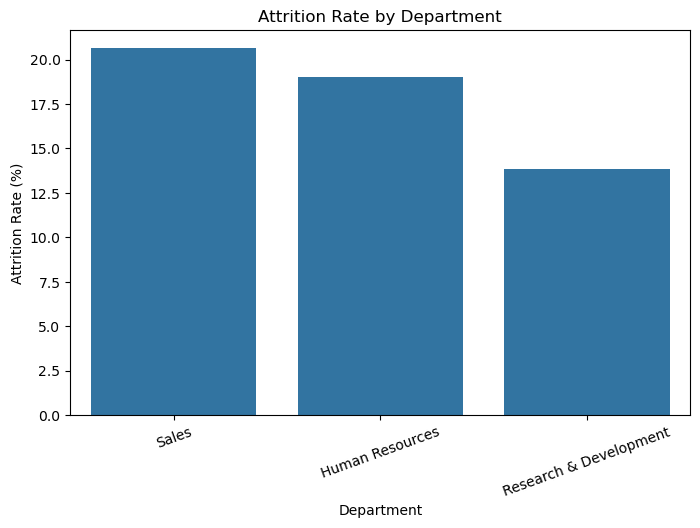

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


In [15]:
#Attrition Rate by Department
department_attrition = (
    df.groupby('Department')['Attrition']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))
sns.barplot(x=department_attrition.index, y=department_attrition.values)
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.title("Attrition Rate by Department")
plt.xticks(rotation=20)
plt.show()

print(department_attrition)

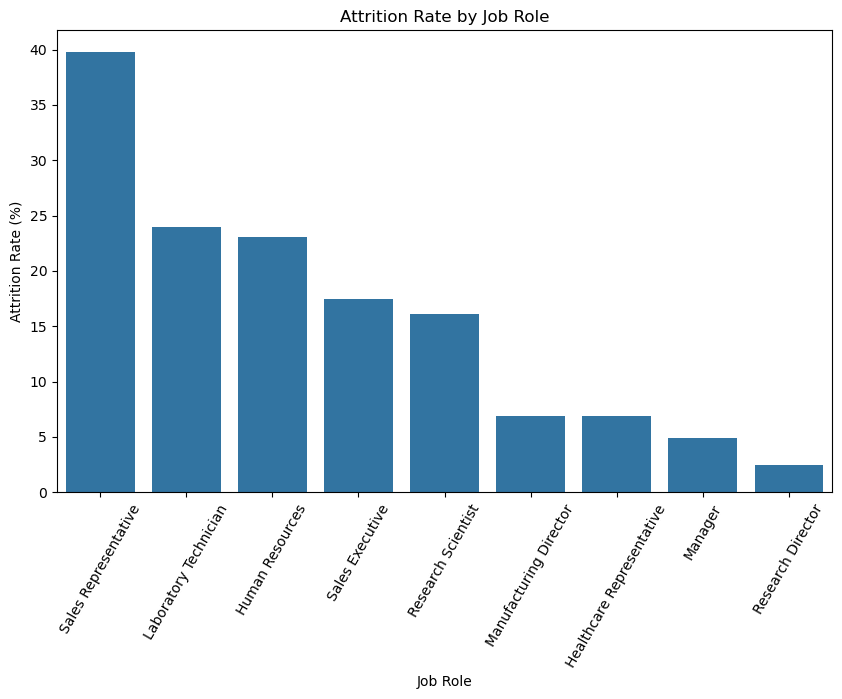

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


In [16]:
#Attrition Rate by Job Role
jobrole_attrition = (
    df.groupby('JobRole')['Attrition']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10,6))
sns.barplot(x=jobrole_attrition.index, y=jobrole_attrition.values)
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")
plt.title("Attrition Rate by Job Role")
plt.xticks(rotation=60)
plt.show()

print(jobrole_attrition)

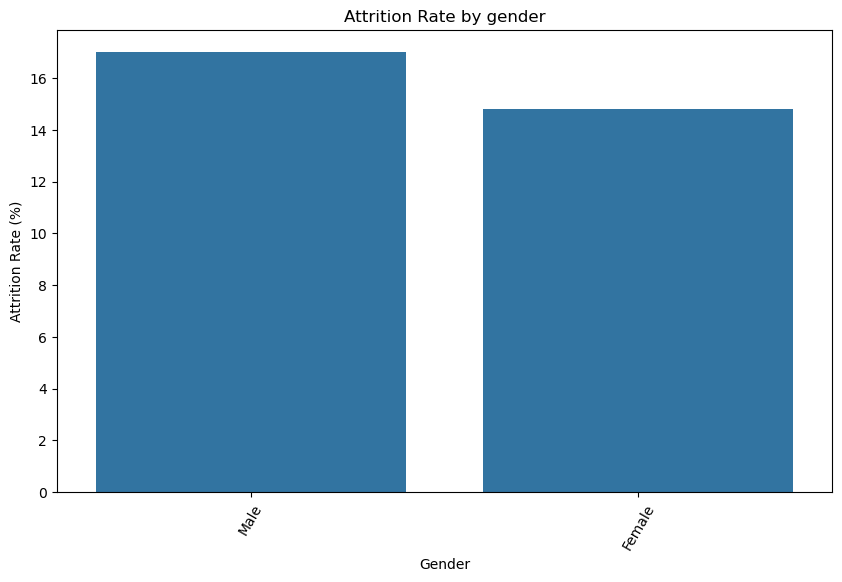

In [17]:
#Attrition Rate by Gender
gender_attrition = (
    df.groupby('Gender')['Attrition']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10,6))
sns.barplot(x=gender_attrition.index, y=gender_attrition.values)
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Gender")
plt.title("Attrition Rate by gender")
plt.xticks(rotation=60)
plt.show()

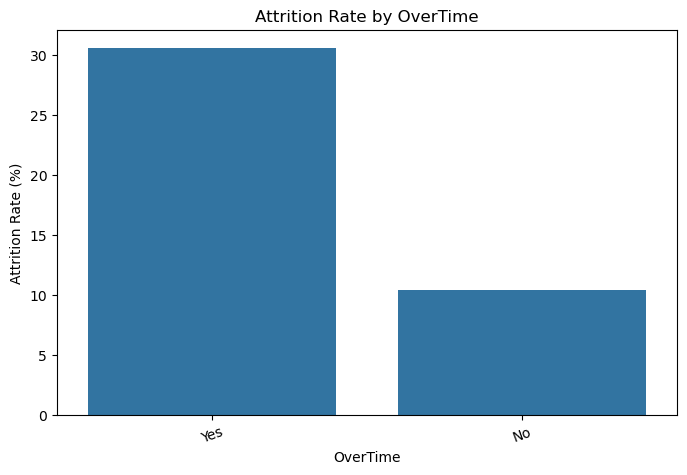

OverTime
Yes    30.528846
No     10.436433
Name: Attrition, dtype: float64


In [18]:
overtime_attrition = (
    df.groupby('OverTime')['Attrition']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))
sns.barplot(x=overtime_attrition.index, y=overtime_attrition.values)
plt.ylabel("Attrition Rate (%)")
plt.xlabel("OverTime")
plt.title("Attrition Rate by OverTime")
plt.xticks(rotation=20)
plt.show()

print(overtime_attrition)

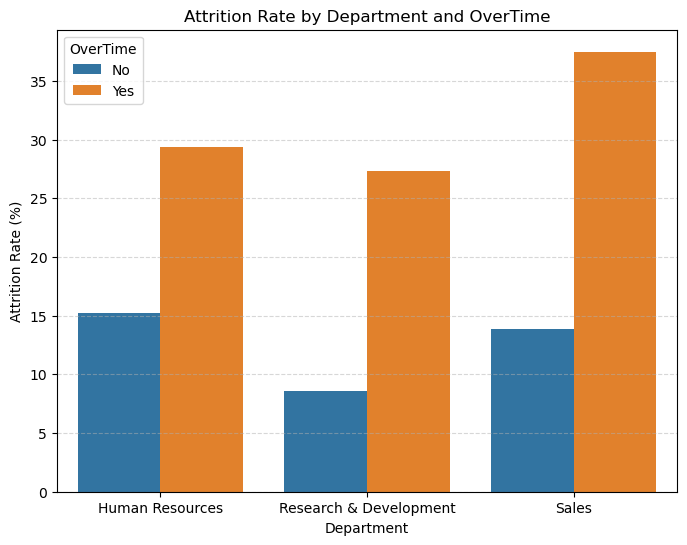

In [19]:
attrition_rate = (
    df.groupby(['Department', 'OverTime'])['Attrition']
      .mean()
      .mul(100)
      .reset_index(name='AttritionRate')
)

# Plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=attrition_rate,
    x='Department',
    y='AttritionRate',
    hue='OverTime'
)

plt.title('Attrition Rate by Department and OverTime')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.legend(title='OverTime')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Employees who work overtime experience an attrition rate of about 31%, compared to about 10% for employees who do not work overtime. This suggests that employees working overtime are roughly three times more likely to leave, indicating that workload and work-life balance may be significant drivers of attrition.

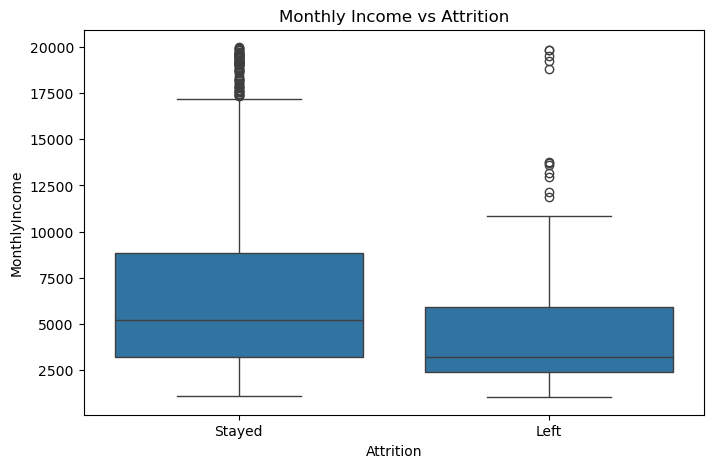

In [20]:
#Monthly Income vs Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

plt.xticks([0,1],["Stayed","Left"])
plt.title("Monthly Income vs Attrition")
plt.show()

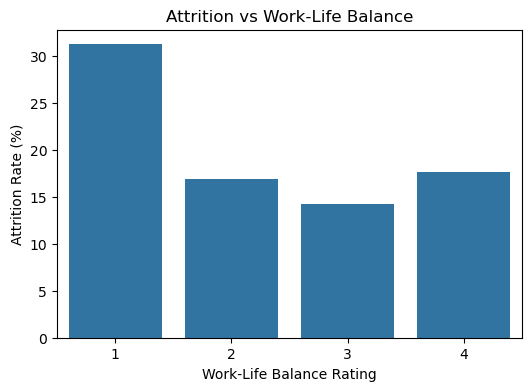

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


In [21]:
#Attrition vs Work-Life Balance
wlb = (
    df.groupby('WorkLifeBalance')['Attrition']
    .mean() * 100
)

plt.figure(figsize=(6,4))
sns.barplot(x=wlb.index, y=wlb.values)

plt.ylabel("Attrition Rate (%)")
plt.xlabel("Work-Life Balance Rating")
plt.title("Attrition vs Work-Life Balance")
plt.show()

print(wlb)

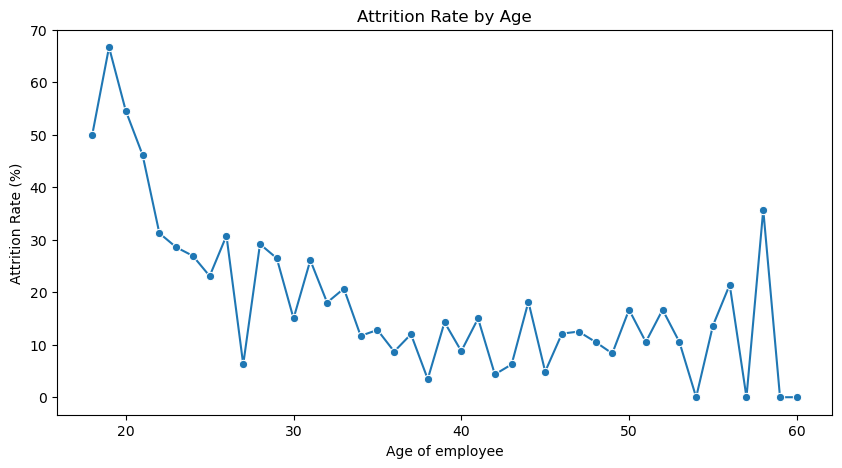

In [22]:
#Attrition Rate by Age
Ages = (
    df.groupby('Age')['Attrition']
    .mean() * 100
)

plt.figure(figsize=(10,5))
sns.lineplot(x=Ages.index, y=Ages.values, marker='o')

plt.ylabel("Attrition Rate (%)")
plt.xlabel("Age of employee")
plt.title("Attrition Rate by Age")
plt.show()

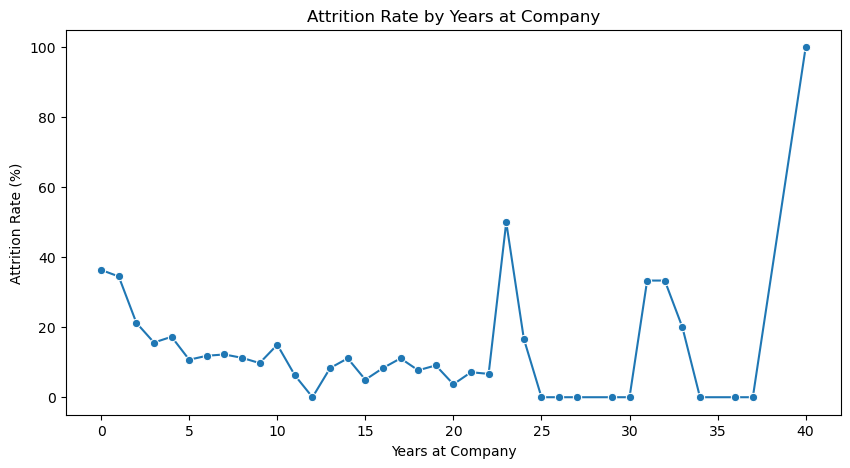

In [23]:
#Attrition Rate by Years at Company
years = (
    df.groupby('YearsAtCompany')['Attrition']
    .mean() * 100
)

plt.figure(figsize=(10,5))
sns.lineplot(x=years.index, y=years.values, marker='o')

plt.ylabel("Attrition Rate (%)")
plt.xlabel("Years at Company")
plt.title("Attrition Rate by Years at Company")
plt.show()


### Insights
- Employees in the Sales department have the highest attrition rate, indicating that this department faces greater retention challenges than the others.
- Sales Representatives experience the highest attrition rate (approximately 40%), followed by Laboratory Technicians (around 24%). This suggests that retention strategies should prioritize these job roles.
- The attrition rate is nearly the same for both male and female employees, indicating that gender does not appear to have a significant influence on employee turnover.
- Employees with the lowest Work-Life Balance rating (1) have the highest attrition rate (around 32%). Interestingly, employees with higher Work-Life - Balance ratings still show an attrition rate of about 25%, suggesting that factors other than work-life balance also contribute to employees leaving the company.
- The attrition rate is highest among younger employees, indicating that early-career employees are more likely to leave the organization. However, the dataset alone does not explain the reason for this pattern.
- Employees who left the company generally have lower monthly incomes than those who stayed, suggesting an association between lower income and higher attrition.

In [24]:
df[df['YearsAtCompany'].between(35, 40)].shape[0]

4

# Model Building

In [25]:
# First we do one hot encoding for all the cateogorical data.
df=pd.get_dummies(df, drop_first=True, dtype=int)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   HourlyRate                         1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked  

In [27]:
#Dividing data into x and y
x=df.drop('Attrition', axis=1)
y=df['Attrition']

In [28]:
#saving the feature names
feature_names = x.columns

In [29]:
#Importing of important library for model building
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay

In [30]:
#Diving into training and testing. Use startify so that the proportions for x and y are the same in both training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

## Logistic Regression

In [32]:
#Creating a evaluation function so that we do not have to rewrite this code for every model.
def evaluate_model(y_test,y_pred,y_prob):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

Now this function reduce lines of codes and help in making matrix where i compare model directly.

In [33]:
#linear regression model
lr = LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000)
lr.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [34]:
y_pred_lr=lr.predict(x_test)
y_prob_lr=lr.predict_proba(x_test)[:, 1]

## Random Forest

In [35]:
#Random Forest Model
rf = RandomForestClassifier(class_weight='balanced',random_state=42)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
y_prob_rf=rf.predict_proba(x_test)[:, 1]

## GB boost
GradientBoostingClassifier does not support the class_weight parameter, so it was trained without class weighting but we can use smote for it.

In [36]:
#Applying smote only for gb boost
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

We can apply smoote to random forest as well as logistic regression but we do not use it.

In [37]:
gb=GradientBoostingClassifier(random_state=42)
gb.fit(x_train_smote, y_train_smote)
y_pred_gb_smote=gb.predict(x_test)
y_prob_gb_smote=gb.predict_proba(x_test)[:, 1]

In [38]:
# we also check model accuracy without smote
gb.fit(x_train, y_train)
y_pred_gb=gb.predict(x_test)
y_prob_gb=gb.predict_proba(x_test)[:, 1]

## Comparision of Model

In [39]:
results = pd.DataFrame({
    "Logistic Regression": evaluate_model(y_test,y_pred_lr,y_prob_lr),
    "Random Forest": evaluate_model(y_test,y_pred_rf,y_prob_rf),
    "Gradient Boosting": evaluate_model(y_test,y_pred_gb,y_prob_gb),
    "Gradient Boosting with smote":evaluate_model(y_test,y_pred_gb_smote,y_prob_gb_smote)
}).T

results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.751701,0.345238,0.617021,0.442748,0.798260
Random Forest,0.836735,0.444444,0.085106,0.142857,0.754716
Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.794125
Gradient Boosting with smote,0.860544,0.607143,0.361702,0.453333,0.809372


In [40]:
#Function for confusion matrix
def confusion_mat(name,y_test,y_pred):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
    )

    plt.title(name)
    plt.show()

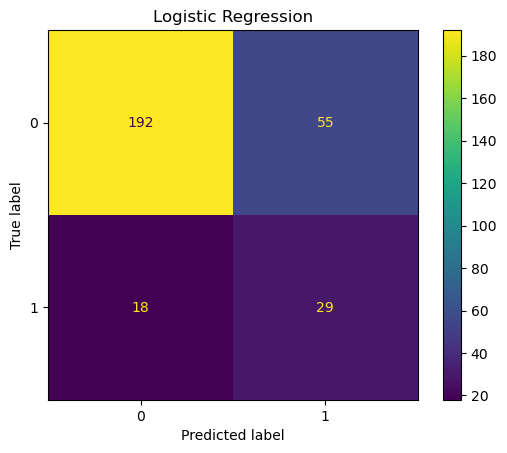

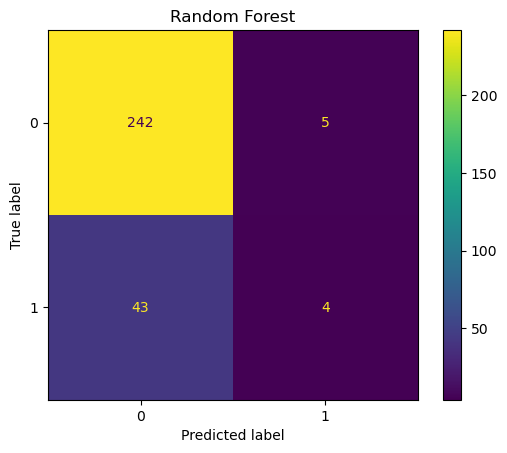

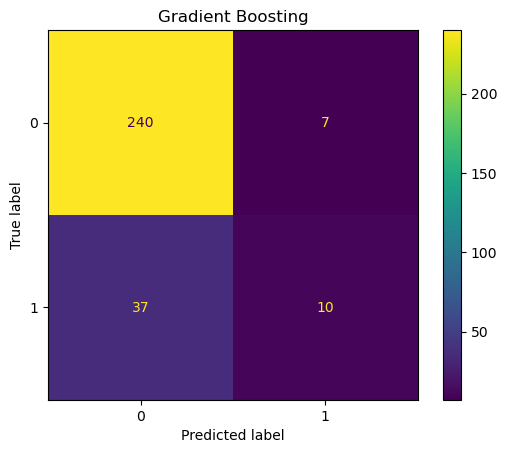

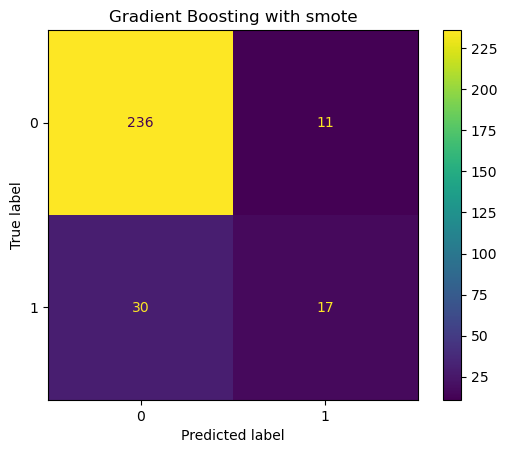

In [41]:
confusion_mat("Logistic Regression",y_test,y_pred_lr)
confusion_mat("Random Forest",y_test,y_pred_rf)
confusion_mat("Gradient Boosting",y_test,y_pred_gb)
confusion_mat("Gradient Boosting with smote",y_test,y_pred_gb_smote)

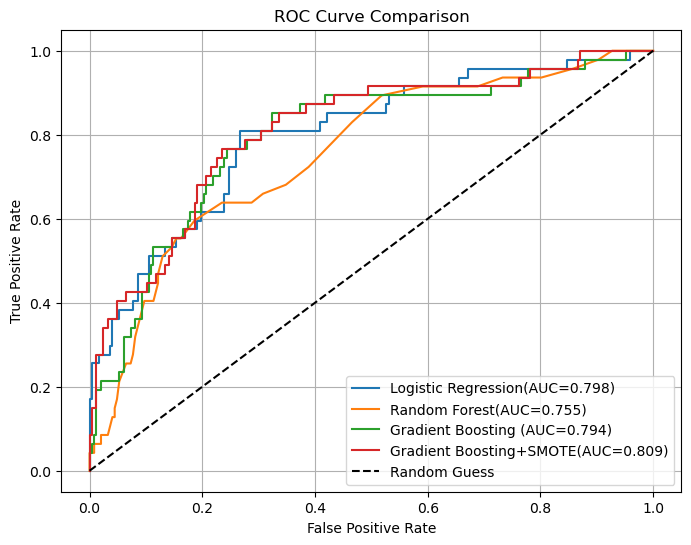

In [42]:
#Auc Roc Curve
from sklearn.metrics import roc_curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob_lr)
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob_rf)
gb_fpr, gb_tpr, _ = roc_curve(y_test, y_prob_gb)
gb_smote_fpr, gb_smote_tpr, _ = roc_curve(y_test, y_prob_gb_smote)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression(AUC={roc_auc_score(y_test,y_prob_lr):.3f})'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest(AUC={roc_auc_score(y_test,y_prob_rf):.3f})'
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f'Gradient Boosting (AUC={roc_auc_score(y_test,y_prob_gb):.3f})'
)

plt.plot(
    gb_smote_fpr,
    gb_smote_tpr,
    label=f'Gradient Boosting+SMOTE(AUC={roc_auc_score(y_test,y_prob_gb_smote):.3f})'
)

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")

plt.grid(True)

plt.show()

## Insights
- If the priority is catching as many at-risk employees as possible, Logistic Regression is the stronger choice because of its much higher recall.
- If the priority is making fewer incorrect alerts while maintaining a balanced overall performance, Gradient Boosting + SMOTE is the stronger choice because it has the best precision, F1-score, ROC-AUC, and far fewer false positives.
- Gradient Boosting with SMOTE achieved the highest ROC-AUC score (≈0.81), demonstrating the best overall discriminative ability.

#### I prefer to go with Gradient Boosting + Smote

In [43]:
type(x_train)

numpy.ndarray

In [44]:
#Finding top 10 feature for gradient boost+smote
importance = pd.Series(
    gb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top10 = importance.head(10)

print(top10)

MonthlyIncome              0.109081
Age                        0.093560
OverTime_Yes               0.088694
TotalWorkingYears          0.084067
NumCompaniesWorked         0.050086
StockOptionLevel           0.047100
DailyRate                  0.045122
YearsWithCurrManager       0.043015
EnvironmentSatisfaction    0.038851
JobInvolvement             0.038142
dtype: float64


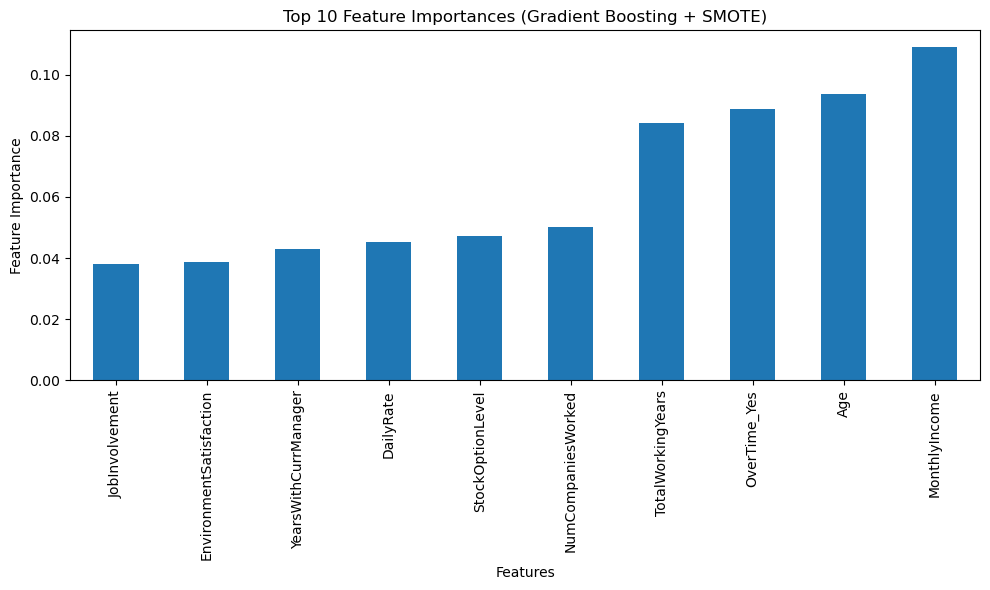

In [45]:
#plotting of important features
plt.figure(figsize=(10,6))
top10.sort_values().plot(kind='bar')
plt.xlabel("Features")
plt.ylabel("Feature Importance")
plt.title("Top 10 Feature Importances (Gradient Boosting + SMOTE)")

plt.tight_layout()
plt.show()

These are the important features that play an important role in model building.

# Summary

- Monthly Income is the most important feature and plays a significant role in predicting employee attrition.
- After **Monthly Income**, **Age** and **OverTime** are the next most influential features in the prediction.
- HR should develop effective retention strategies for employees in the Sales** department. One important observation is that sales employees who work overtime have a much higher attrition rate, so reducing excessive overtime should be a priority.
- Although Monthly Income is the most important predictor, it alone cannot explain attrition. Other factors such as Age and OverTime also contribute significantly to the prediction.
- HR should focus on reducing excessive overtime and providing additional benefits to experienced employees, as they contribute valuable knowledge to the company. At the same time, the company should continue creating growth opportunities and attractive benefits for younger employees to improve retention.
- The choice of the prediction model depends on the business objective. If HR's priority is to identify as many employees at risk of leaving as possible, Logistic Regression is the better choice because of its higher recall. If HR wants a more balanced model with better overall performance, Gradient Boosting with SMOTE is the preferred model.

# Recommendations for HR

- When the model predicts that an employee is likely to leave, HR should investigate the underlying reasons, such as excessive overtime, low salary, or other workplace issues, and take appropriate actions to address them.
- HR should introduce additional benefits and retention programs for the Sales team. This may include increasing incentives, reducing excessive overtime, setting more realistic performance targets, and maintaining a healthy work-life balance. These measures can help reduce attrition while ensuring the company continues to achieve its business goals.


# Limitations of our model
- Even the best model misses some employees who actually leave (false negatives). Therefore, it should be used as a decision-support tool rather than replacing HR judgment.
- The model identifies patterns associated with attrition but cannot determine the actual cause of an employee leaving. For example, lower salary is associated with higher attrition, but the model cannot conclude that salary is the sole reason.